In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

True

# Data Agent


### STATE


In [2]:
from typing import TypedDict, Optional


class DataAgentState(TypedDict):
    symbol: str
    period: str

    current_price: Optional[float]
    open_price: Optional[float]
    high_52w: Optional[float]
    low_52w: Optional[float]
    volume: Optional[int]
    avg_volume: Optional[int]
    price_history: Optional[list[dict]]
    price_change_pct: Optional[float]

    market_cap: Optional[float]
    pe_ratio: Optional[float]
    eps: Optional[float]
    revenue: Optional[float]
    profit_margin: Optional[float]
    dividend_yield: Optional[float]
    beta: Optional[float]
    sector: Optional[str]
    industry: Optional[str]
    description: Optional[str]

    price_fetch_success: Optional[bool]
    fundamentals_fetch_success: Optional[bool]
    retry_count: Optional[int]
    errors: Optional[list[str]]

    data_ready: Optional[bool]
    summary: Optional[str]

In [3]:
test_state: DataAgentState = {
    "symbol": "AAPL",
    "period": "1y",
    "current_price": None,
    "open_price": None,
    "high_52w": None,
    "low_52w": None,
    "volume": None,
    "avg_volume": None,
    "price_history": None,
    "price_change_pct": None,
    "market_cap": None,
    "pe_ratio": None,
    "eps": None,
    "revenue": None,
    "profit_margin": None,
    "dividend_yield": None,
    "beta": None,
    "sector": None,
    "industry": None,
    "description": None,
    "price_fetch_success": None,
    "fundamentals_fetch_success": None,
    "retry_count": 0,
    "errors": [],
    "data_ready": None,
    "summary": None,
}

### Fetch price node


In [4]:
import yfinance as yf
from datetime import datetime


def fetch_price_node(state: DataAgentState) -> dict:
    symbol = state["symbol"]
    period = state["period"]
    errors = state["errors"]

    print(f"📈 Fetching price data for {symbol}...")

    try:
        ticker = yf.Ticker(symbol)
        info = ticker.info
        current_price = (
            info.get("currentPrice")
            or info.get("regularMarketPrice")
            or info.get("previousClose")
        )
        high_52w = info.get("fiftyTwoWeekHigh")
        low_52w = info.get("fiftyTwoWeekLow")
        volume = info.get("volume") or info.get("regularMarketVolume")
        avg_volume = info.get("averageVolume")
        open_price = info.get("open") or info.get("regularMarketOpen")
        hist = ticker.history(period=period)
        if hist.empty:
            raise ValueError(f"No price history found for {symbol}")

        price_history = [
            {
                "date": str(idx.date()),
                "open": round(row["Open"], 2),
                "high": round(row["High"], 2),
                "low": round(row["Low"], 2),
                "close": round(row["Close"], 2),
                "volume": int(row["Volume"]),
            }
            for idx, row in hist.iterrows()
        ]
        if len(price_history) >= 2:
            first_close = price_history[0]["close"]
            last_close = price_history[-1]["close"]
            price_change_pct = round(
                ((last_close - first_close) / first_close) * 100, 2
            )
        else:
            price_change_pct = 0.0

        print(f"✅ fetch_price_node → {symbol} @ ${current_price}")
        print(f"   52w High: ${high_52w} | 52w Low: ${low_52w}")
        print(f"   Price change ({period}): {price_change_pct}%")
        print(f"   History records: {len(price_history)}")

        return {
            "current_price": current_price,
            "open_price": open_price,
            "high_52w": high_52w,
            "low_52w": low_52w,
            "volume": volume,
            "avg_volume": avg_volume,
            "price_history": price_history,
            "price_change_pct": price_change_pct,
            "price_fetch_success": True,
            "errors": errors,
        }
    except Exception as e:
        error_msg = f"fetch_price_node error: {str(e)}"
        print(f"❌ {error_msg}")
        return {
            "price_fetch_success": False,
            "errors": errors + [error_msg],
        }

In [5]:
test_symbols = ["AAPL", "GOOGL", "MSFT"]

for symbol in test_symbols:
    print(f"\n{'=' * 50}")
    result = fetch_price_node({**test_state, "symbol": symbol})
    print(f"Success:    {result['price_fetch_success']}")
    print(f"Price:      ${result.get('current_price')}")
    print(f"Change:     {result.get('price_change_pct')}%")
    print(f"History:    {len(result.get('price_history', []))} records")


📈 Fetching price data for AAPL...
✅ fetch_price_node → AAPL @ $298.01
   52w High: $317.4 | 52w Low: $198.96
   Price change (1y): 48.85%
   History records: 251
Success:    True
Price:      $298.01
Change:     48.85%
History:    251 records

📈 Fetching price data for GOOGL...
✅ fetch_price_node → GOOGL @ $368.03
   52w High: $408.61 | 52w Low: $162.0
   Price change (1y): 121.48%
   History records: 251
Success:    True
Price:      $368.03
Change:     121.48%
History:    251 records

📈 Fetching price data for MSFT...
✅ fetch_price_node → MSFT @ $379.4
   52w High: $555.45 | 52w Low: $356.28
   Price change (1y): -19.89%
   History records: 251
Success:    True
Price:      $379.4
Change:     -19.89%
History:    251 records


### Fetch Fundamentals Node


In [6]:
import requests

ALPHA_VANTAGE_BASE = "https://www.alphavantage.co/query"


def safe_float(val):
    try:
        return float(val) if val and val != "None" else None
    except Exception:
        return None


def fetch_fundamentals_node(state: DataAgentState) -> dict:
    symbol = state["symbol"]
    api_key = os.getenv("ALPHA_VANTAGE_API_KEY")
    errors = state.get("errors", [])

    print(f"📊 Fetching fundamentals for {symbol}...")

    try:
        response = requests.get(
            ALPHA_VANTAGE_BASE,
            params={"function": "OVERVIEW", "symbol": symbol, "apikey": api_key},
        )
        data = response.json()

        if "Note" in data:
            raise ValueError("Alpha Vantage rate limit hit — wait 1 minute")

        if not data or "Symbol" not in data:
            raise ValueError(f"No fundamental data found for {symbol}")

        market_cap = safe_float(data.get("MarketCapitalization"))
        pe_ratio = safe_float(data.get("PERatio"))
        eps = safe_float(data.get("EPS"))
        revenue = safe_float(data.get("RevenueTTM"))
        profit_margin = safe_float(data.get("ProfitMargin"))
        dividend_yield = safe_float(data.get("DividendYield"))
        beta = safe_float(data.get("Beta"))
        sector = data.get("Sector")
        industry = data.get("Industry")
        description = data.get("Description", "")

        print(f"✅ fetch_fundamentals_node → {symbol}")
        print(
            f"   Market Cap:    ${market_cap:,.0f}"
            if market_cap
            else "   Market Cap: N/A"
        )
        print(f"   P/E Ratio:     {pe_ratio}")
        print(f"   EPS:           {eps}")
        print(f"   Profit Margin: {profit_margin}")
        print(f"   Sector:        {sector}")
        print(f"   Industry:      {industry}")

        return {
            "market_cap": market_cap,
            "pe_ratio": pe_ratio,
            "eps": eps,
            "revenue": revenue,
            "profit_margin": profit_margin,
            "dividend_yield": dividend_yield,
            "beta": beta,
            "sector": sector,
            "industry": industry,
            "description": description,
            "fundamentals_fetch_success": True,
            "errors": errors,
        }
    except Exception as e:
        error_msg = f"fetch_fundamentals_node error: {str(e)}"
        print(f"❌ {error_msg}")
        return {
            "fundamentals_fetch_success": False,
            "errors": errors + [error_msg],
        }


In [7]:
result = fetch_fundamentals_node({**test_state, "symbol": "AAPL"})

print(f"\nSuccess:       {result['fundamentals_fetch_success']}")
print(f"Market Cap:    ${result.get('market_cap', 0):,.0f}")
print(f"P/E Ratio:     {result.get('pe_ratio')}")
print(f"EPS:           {result.get('eps')}")
print(f"Revenue:       ${result.get('revenue', 0):,.0f}")
print(f"Profit Margin: {result.get('profit_margin')}")
print(f"Beta:          {result.get('beta')}")
print(f"Sector:        {result.get('sector')}")
print(f"Description:        {result.get('description')}")

📊 Fetching fundamentals for AAPL...
❌ fetch_fundamentals_node error: No fundamental data found for AAPL

Success:       False
Market Cap:    $0
P/E Ratio:     None
EPS:           None
Revenue:       $0
Profit Margin: None
Beta:          None
Sector:        None
Description:        None


### Validate Node


In [8]:
MAX_RETRIES = 2


def validate_node(state: DataAgentState) -> dict:
    price_ok = state.get("price_fetch_success", False)
    fundamentals_ok = state.get("fundamentals_fetch_success", False)
    retry_count = state.get("retry_count", 0)
    errors = state.get("errors", [])
    symbol = state["symbol"]

    print(f"🔍 Validating data for {symbol}...")
    print(f"   Price fetch:        {'✅' if price_ok else '❌'}")
    print(f"   Fundamentals fetch: {'✅' if fundamentals_ok else '❌'}")
    print(f"   Retry count:        {retry_count}/{MAX_RETRIES}")

    if price_ok and fundamentals_ok:
        print("✅ validate_node → All data valid, proceeding")
        return {
            "data_ready": True,
            "retry_count": retry_count,
            "errors": errors,
        }

    if retry_count < MAX_RETRIES:
        print(
            f"⚠️  validate_node → Incomplete data, retrying ({retry_count + 1}/{MAX_RETRIES})"
        )
        return {
            "data_ready": False,
            "retry_count": retry_count + 1,
            "errors": errors,
        }

    print("⚠️  validate_node → Max retries hit, proceeding with partial data")
    return {
        "data_ready": True,
        "retry_count": retry_count,
        "errors": errors + [f"Max retries hit for {symbol} — partial data"],
    }

### Summary Node


In [9]:
from groq import Groq

groq_client = Groq(api_key=os.getenv("GROQ_API_KEY"))

In [10]:
def summary_node(state: DataAgentState) -> dict:
    symbol = state["symbol"]
    errors = state.get("errors", [])

    print(f"📝 Generating data summary for {symbol}...")
    price_section = (
        f"""
        PRICE DATA ({symbol}):
        - Current Price:    ${state.get("current_price", "N/A")}
        - 52-Week High:     ${state.get("high_52w", "N/A")}
        - 52-Week Low:      ${state.get("low_52w", "N/A")}
        - Price Change:     {state.get("price_change_pct", "N/A")}% over {state.get("period", "1y")}
        - Volume:           {state.get("volume", "N/A"):,} (Avg: {state.get("avg_volume", "N/A"):,})
        """
        if state.get("price_fetch_success")
        else "PRICE DATA: Unavailable"
    )

    fundamentals_section = (
        f"""
        FUNDAMENTALS ({symbol}):
        - Market Cap:       ${state.get("market_cap", 0):,.0f}
        - P/E Ratio:        {state.get("pe_ratio", "N/A")}
        - EPS:              {state.get("eps", "N/A")}
        - Revenue (TTM):    ${state.get("revenue", 0):,.0f}
        - Profit Margin:    {state.get("profit_margin", "N/A")}
        - Dividend Yield:   {state.get("dividend_yield", "N/A")}
        - Beta:             {state.get("beta", "N/A")}
        - Sector:           {state.get("sector", "N/A")}
        - Industry:         {state.get("industry", "N/A")}
        """
        if state.get("fundamentals_fetch_success")
        else "FUNDAMENTALS: Unavailable"
    )

    prompt = f"""
    You are a financial data analyst. Based on the following raw data,
    write a concise 3-4 sentence factual summary of {symbol}'s current
    financial position. No recommendations — just facts.

    {price_section}
    {fundamentals_section}
    """

    try:
        response = groq_client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[{"role": "user", "content": prompt}],
            temperature=0.1,
        )
        summary = response.choices[0].message.content.strip()
        print("✅ summary_node → Summary generated")
        print("\n── Summary ──────────────────────────────")
        print(summary)

        return {"summary": summary, "errors": errors}

    except Exception as e:
        error_msg = f"summary_node error: {str(e)}"
        print(f"❌ {error_msg}")
        return {
            "summary": f"Summary unavailable for {symbol}",
            "errors": errors + [error_msg],
        }

In [11]:
price_result = fetch_price_node({**test_state, "symbol": "AAPL"})
fundamentals_result = fetch_fundamentals_node({**test_state, "symbol": "AAPL"})

full_state = {
    **test_state,
    **price_result,
    **fundamentals_result,
}

summary_result = summary_node(full_state)

📈 Fetching price data for AAPL...
✅ fetch_price_node → AAPL @ $298.01
   52w High: $317.4 | 52w Low: $198.96
   Price change (1y): 48.85%
   History records: 251
📊 Fetching fundamentals for AAPL...
❌ fetch_fundamentals_node error: No fundamental data found for AAPL
📝 Generating data summary for AAPL...
✅ summary_node → Summary generated

── Summary ──────────────────────────────
AAPL's current stock price is $298.01, which is below its 52-week high of $317.40 but significantly above its 52-week low of $198.96. The stock has experienced a 48.85% price increase over the past year. The current trading volume is 85,962,201, exceeding the average volume of 47,300,354. As of the current price, AAPL's stock is approximately $19.39 below its 52-week high.


### Graph Setup


In [12]:
from langgraph.graph import StateGraph, END


def should_retry(state: DataAgentState) -> str:
    if not state.get("data_ready") and state.get("retry_count", 0) < MAX_RETRIES:
        return "fetch_price_node"
    return "summary_node"

In [13]:
def build_data_agent() -> any:
    graph = StateGraph(DataAgentState)

    graph.add_node("fetch_price_node", fetch_price_node)
    graph.add_node("fetch_fundamentals_node", fetch_fundamentals_node)
    graph.add_node("validate_node", validate_node)
    graph.add_node("summary_node", summary_node)

    graph.set_entry_point("fetch_price_node")

    graph.add_edge("fetch_price_node", "fetch_fundamentals_node")
    graph.add_edge("fetch_fundamentals_node", "validate_node")

    graph.add_conditional_edges(
        "validate_node",
        should_retry,
        {
            "fetch_price_node": "fetch_price_node",
            "summary_node": "summary_node",
        },
    )

    graph.add_edge("summary_node", END)

    return graph.compile()

In [14]:
data_agent = build_data_agent()

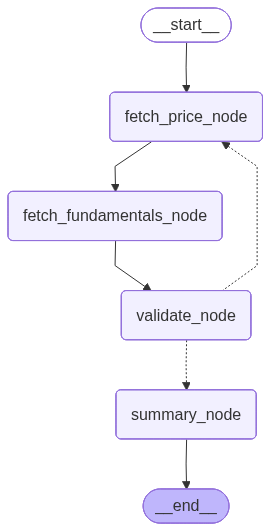

In [15]:
from IPython.display import Image, display

display(Image(data_agent.get_graph().draw_mermaid_png()))

In [16]:
test_symbols = ["AAPL", "MSFT", "GOOGL"]

for symbol in test_symbols:
    print(f"\n{'=' * 60}")
    print(f"Running Data Agent for: {symbol}")
    print("=" * 60)

    initial_state = {
        "symbol": symbol,
        "period": "1y",
        "retry_count": 0,
        "errors": [],
    }

    result = data_agent.invoke(initial_state)

    print("\n── Final Output ─────────────────────────────")
    print(f"Symbol:         {result['symbol']}")
    print(f"Current Price:  ${result.get('current_price')}")
    print(f"Market Cap:     ${result.get('market_cap', 0):,.0f}")
    print(f"P/E Ratio:      {result.get('pe_ratio')}")
    print(f"Price Change:   {result.get('price_change_pct')}%")
    print(f"Data Ready:     {result.get('data_ready')}")
    print(f"Errors:         {result.get('errors')}")
    print(f"\nSummary:\n{result.get('summary')}")


Running Data Agent for: AAPL
📈 Fetching price data for AAPL...
✅ fetch_price_node → AAPL @ $298.01
   52w High: $317.4 | 52w Low: $198.96
   Price change (1y): 48.85%
   History records: 251
📊 Fetching fundamentals for AAPL...
❌ fetch_fundamentals_node error: No fundamental data found for AAPL
🔍 Validating data for AAPL...
   Price fetch:        ✅
   Fundamentals fetch: ❌
   Retry count:        0/2
⚠️  validate_node → Incomplete data, retrying (1/2)
📈 Fetching price data for AAPL...
✅ fetch_price_node → AAPL @ $298.01
   52w High: $317.4 | 52w Low: $198.96
   Price change (1y): 48.85%
   History records: 251
📊 Fetching fundamentals for AAPL...
❌ fetch_fundamentals_node error: No fundamental data found for AAPL
🔍 Validating data for AAPL...
   Price fetch:        ✅
   Fundamentals fetch: ❌
   Retry count:        1/2
⚠️  validate_node → Incomplete data, retrying (2/2)
📝 Generating data summary for AAPL...
✅ summary_node → Summary generated

── Summary ──────────────────────────────
AAPL

# Analysis Agent


In [17]:
aapl_data = data_agent.invoke(
    {"symbol": "AAPL", "period": "1y", "retry_count": 0, "errors": []}
)

print(f"✅ AAPL data ready — price: ${aapl_data['current_price']}")

📈 Fetching price data for AAPL...
✅ fetch_price_node → AAPL @ $298.01
   52w High: $317.4 | 52w Low: $198.96
   Price change (1y): 48.85%
   History records: 251
📊 Fetching fundamentals for AAPL...
❌ fetch_fundamentals_node error: No fundamental data found for AAPL
🔍 Validating data for AAPL...
   Price fetch:        ✅
   Fundamentals fetch: ❌
   Retry count:        0/2
⚠️  validate_node → Incomplete data, retrying (1/2)
📈 Fetching price data for AAPL...
✅ fetch_price_node → AAPL @ $298.01
   52w High: $317.4 | 52w Low: $198.96
   Price change (1y): 48.85%
   History records: 251
📊 Fetching fundamentals for AAPL...
❌ fetch_fundamentals_node error: No fundamental data found for AAPL
🔍 Validating data for AAPL...
   Price fetch:        ✅
   Fundamentals fetch: ❌
   Retry count:        1/2
⚠️  validate_node → Incomplete data, retrying (2/2)
📝 Generating data summary for AAPL...
✅ summary_node → Summary generated

── Summary ──────────────────────────────
AAPL's current stock price is $298

In [18]:
from typing import TypedDict, Optional, Literal


class AnalysisAgentState(TypedDict):
    symbol: str
    current_price: Optional[float]
    high_52w: Optional[float]
    low_52w: Optional[float]
    price_change_pct: Optional[float]
    price_history: Optional[list[dict]]
    pe_ratio: Optional[float]
    eps: Optional[float]
    market_cap: Optional[float]
    revenue: Optional[float]
    profit_margin: Optional[float]
    beta: Optional[float]
    dividend_yield: Optional[float]
    sector: Optional[str]
    data_summary: Optional[str]

    sma_20: Optional[float]
    sma_50: Optional[float]
    sma_200: Optional[float]
    rsi: Optional[float]
    macd: Optional[float]
    macd_signal: Optional[float]
    volatility: Optional[float]

    price_vs_52w_high: Optional[float]
    price_vs_52w_low: Optional[float]
    golden_cross: Optional[bool]
    death_cross: Optional[bool]

    pe_signal: Optional[str]
    margin_signal: Optional[str]
    momentum_signal: Optional[str]

    risk_score: Optional[float]
    risk_label: Optional[str]
    recommendation: Optional[
        Literal["strong_buy", "buy", "hold", "sell", "strong_sell"]
    ]
    reasoning: Optional[str]

    errors: Optional[list[str]]

In [19]:
# initialise from AAPL data agent output
analysis_test_state: AnalysisAgentState = {
    "symbol": aapl_data["symbol"],
    "current_price": aapl_data["current_price"],
    "high_52w": aapl_data["high_52w"],
    "low_52w": aapl_data["low_52w"],
    "price_change_pct": aapl_data["price_change_pct"],
    "price_history": aapl_data["price_history"],
    "pe_ratio": aapl_data["pe_ratio"],
    "eps": aapl_data["eps"],
    "market_cap": aapl_data["market_cap"],
    "revenue": aapl_data["revenue"],
    "profit_margin": aapl_data["profit_margin"],
    "beta": aapl_data["beta"],
    "dividend_yield": aapl_data["dividend_yield"],
    "sector": aapl_data["sector"],
    "data_summary": aapl_data["summary"],
    "errors": [],
}


KeyError: 'pe_ratio'

### Technical Node


In [20]:
import numpy as np
import pandas as pd

In [21]:
def technical_node(state: AnalysisAgentState) -> dict:
    symbol = state["symbol"]
    price_history = state.get("price_history", [])
    current_price = state.get("current_price")
    high_52w = state.get("high_52w")
    low_52w = state.get("low_52w")
    errors = state.get("errors", [])

    print(f"📐 Calculating technical indicators for {symbol}...")

    if not price_history or len(price_history) < 20:
        error_msg = f"Insufficient price history for {symbol}"
        print(f"❌ {error_msg}")
        return {"errors": errors + [error_msg]}

    df = pd.DataFrame(price_history)
    closes = df["close"].astype(float)

    sma_20 = round(closes.tail(20).mean(), 2)
    sma_50 = round(closes.tail(50).mean(), 2) if len(closes) >= 50 else None
    sma_200 = round(closes.tail(200).mean(), 2) if len(closes) >= 200 else None

    delta = closes.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.tail(14).mean()
    avg_loss = loss.tail(14).mean()
    rs = avg_gain / avg_loss if avg_loss != 0 else 0
    rsi = round(100 - (100 / (1 + rs)), 2)

    ema_12 = closes.ewm(span=12, adjust=False).mean()
    ema_26 = closes.ewm(span=26, adjust=False).mean()
    macd_line = ema_12 - ema_26
    signal_line = macd_line.ewm(span=9, adjust=False).mean()
    macd = round(macd_line.iloc[-1], 4)
    macd_signal = round(signal_line.iloc[-1], 4)

    daily_returns = closes.pct_change().dropna()
    volatility = round(daily_returns.std() * np.sqrt(252) * 100, 2)

    price_vs_52w_high = (
        round(((current_price - high_52w) / high_52w) * 100, 2) if high_52w else None
    )
    price_vs_52w_low = (
        round(((current_price - low_52w) / low_52w) * 100, 2) if low_52w else None
    )

    golden_cross = bool(sma_20 > sma_50) if sma_50 else None
    death_cross = bool(sma_20 < sma_50) if sma_50 else None

    print(f"✅ technical_node → {symbol}")
    print(f"   SMA20:  ${sma_20} | SMA50: ${sma_50} | SMA200: ${sma_200}")
    print(f"   RSI:    {rsi}")
    print(f"   MACD:   {macd} | Signal: {macd_signal}")
    print(f"   Volatility: {volatility}%")
    print(f"   vs 52w High: {price_vs_52w_high}% | vs 52w Low: +{price_vs_52w_low}%")
    print(f"   Golden Cross: {golden_cross} | Death Cross: {death_cross}")

    return {
        "sma_20": sma_20,
        "sma_50": sma_50,
        "sma_200": sma_200,
        "rsi": rsi,
        "macd": macd,
        "macd_signal": macd_signal,
        "volatility": volatility,
        "price_vs_52w_high": price_vs_52w_high,
        "price_vs_52w_low": price_vs_52w_low,
        "golden_cross": golden_cross,
        "death_cross": death_cross,
        "errors": errors,
    }

In [22]:
tech_result = technical_node(analysis_test_state)

print(f"\nSMA 20:      ${tech_result.get('sma_20')}")
print(f"SMA 50:      ${tech_result.get('sma_50')}")
print(f"SMA 200:     ${tech_result.get('sma_200')}")
print(f"RSI:         {tech_result.get('rsi')}")
print(f"MACD:        {tech_result.get('macd')}")
print(f"Volatility:  {tech_result.get('volatility')}%")
print(f"Golden Cross:{tech_result.get('golden_cross')}")

📐 Calculating technical indicators for AAPL...
✅ technical_node → AAPL
   SMA20:  $303.4 | SMA50: $288.63 | SMA200: $267.79
   RSI:    39.07
   MACD:   1.2073 | Signal: 3.251
   Volatility: 22.63%
   vs 52w High: -6.11% | vs 52w Low: +49.78%
   Golden Cross: True | Death Cross: False

SMA 20:      $303.4
SMA 50:      $288.63
SMA 200:     $267.79
RSI:         39.07
MACD:        1.2073
Volatility:  22.63%
Golden Cross:True


### Valuation Node


In [23]:
def valuation_node(state: AnalysisAgentState) -> dict:
    symbol = state["symbol"]
    pe_ratio = state.get("pe_ratio")
    profit_margin = state.get("profit_margin")
    price_change = state.get("price_change_pct")
    rsi = state.get("rsi")
    macd = state.get("macd")
    macd_signal = state.get("macd_signal")
    errors = state.get("errors", [])

    print(f"💰 Calculating valuation signals for {symbol}...")

    if pe_ratio is None:
        pe_signal = "unknown"
    elif pe_ratio < 15:
        pe_signal = "undervalued"
    elif pe_ratio < 25:
        pe_signal = "fair"
    elif pe_ratio < 40:
        pe_signal = "slightly_overvalued"
    else:
        pe_signal = "overvalued"

    if profit_margin is None:
        margin_signal = "unknown"
    elif profit_margin >= 0.30:
        margin_signal = "strong"
    elif profit_margin >= 0.15:
        margin_signal = "moderate"
    elif profit_margin >= 0.05:
        margin_signal = "weak"
    else:
        margin_signal = "negative"

    bullish_signals = 0
    bearish_signals = 0

    if price_change and price_change > 10:
        bullish_signals += 1
    elif price_change and price_change < -10:
        bearish_signals += 1

    if rsi:
        if rsi < 30:
            bullish_signals += 1
        elif rsi > 70:
            bearish_signals += 1

    if macd and macd_signal:
        if macd > macd_signal:
            bullish_signals += 1
        else:
            bearish_signals += 1

    if bullish_signals > bearish_signals:
        momentum_signal = "bullish"
    elif bearish_signals > bullish_signals:
        momentum_signal = "bearish"
    else:
        momentum_signal = "neutral"

    print(f"✅ valuation_node → {symbol}")
    print(f"   P/E Signal:      {pe_signal} (P/E: {pe_ratio})")
    print(f"   Margin Signal:   {margin_signal} (margin: {profit_margin})")
    print(f"   Momentum Signal: {momentum_signal}")
    print(f"   Bullish: {bullish_signals} | Bearish: {bearish_signals}")

    return {
        "pe_signal": pe_signal,
        "margin_signal": margin_signal,
        "momentum_signal": momentum_signal,
        "errors": errors,
    }

In [24]:
# combine tech result into state
valuation_state = {**analysis_test_state, **tech_result}
val_result = valuation_node(valuation_state)

print(f"\nP/E Signal:      {val_result.get('pe_signal')}")
print(f"Margin Signal:   {val_result.get('margin_signal')}")
print(f"Momentum Signal: {val_result.get('momentum_signal')}")

💰 Calculating valuation signals for AAPL...
✅ valuation_node → AAPL
   P/E Signal:      slightly_overvalued (P/E: 36.08)
   Margin Signal:   moderate (margin: 0.272)
   Momentum Signal: neutral
   Bullish: 1 | Bearish: 1

P/E Signal:      slightly_overvalued
Margin Signal:   moderate
Momentum Signal: neutral


### Risk Node


In [25]:
def risk_node(state: AnalysisAgentState) -> dict:
    symbol = state["symbol"]
    beta = state.get("beta")
    volatility = state.get("volatility")
    rsi = state.get("rsi")
    pe_signal = state.get("pe_signal")
    price_vs_52w_high = state.get("price_vs_52w_high")
    momentum_signal = state.get("momentum_signal")
    errors = state.get("errors", [])

    print(f"⚠️  Calculating risk score for {symbol}...")

    risk_score = 5.0

    if beta:
        if beta > 1.5:
            risk_score += 1.5
        elif beta > 1.2:
            risk_score += 0.8
        elif beta < 0.8:
            risk_score -= 0.5

    if volatility:
        if volatility > 40:
            risk_score += 1.5
        elif volatility > 25:
            risk_score += 0.8
        elif volatility < 15:
            risk_score -= 0.5

    if rsi:
        if rsi > 75:
            risk_score += 1.0
        elif rsi < 25:
            risk_score += 0.5
        elif 40 <= rsi <= 60:
            risk_score -= 0.5

    if pe_signal == "overvalued":
        risk_score += 1.0
    elif pe_signal == "undervalued":
        risk_score -= 0.5

    if price_vs_52w_high:
        if price_vs_52w_high > -5:
            risk_score += 0.5
        elif price_vs_52w_high < -30:
            risk_score += 1.0

    if momentum_signal == "bearish":
        risk_score += 0.5
    elif momentum_signal == "bullish":
        risk_score -= 0.5

    risk_score = round(max(0.0, min(10.0, risk_score)), 2)

    if risk_score <= 3.5:
        risk_label = "low"
    elif risk_score <= 6.5:
        risk_label = "medium"
    else:
        risk_label = "high"

    print(f"✅ risk_node → {symbol}")
    print(f"   Risk Score: {risk_score}/10")
    print(f"   Risk Label: {risk_label}")

    return {
        "risk_score": risk_score,
        "risk_label": risk_label,
        "errors": errors,
    }


In [26]:
risk_state = {**analysis_test_state, **tech_result, **val_result}
risk_result = risk_node(risk_state)

print(f"\nRisk Score: {risk_result.get('risk_score')}/10")
print(f"Risk Label: {risk_result.get('risk_label')}")

⚠️  Calculating risk score for AAPL...
✅ risk_node → AAPL
   Risk Score: 5.0/10
   Risk Label: medium

Risk Score: 5.0/10
Risk Label: medium


### Recommendation Node


In [27]:
RECOMMENDATION_PROMPT = """
You are a senior financial analyst. Based on the following analysis data,
provide a stock recommendation and detailed reasoning.

You MUST respond ONLY with valid JSON in this exact format:
{{
    "recommendation": "buy",
    "reasoning": "3-4 sentence explanation"
}}

Valid recommendation values: "strong_buy", "buy", "hold", "sell", "strong_sell"

Rules:
- Base recommendation strictly on the data provided
- No personal opinions — only data-driven conclusions
- reasoning must reference specific metrics from the data
- Never recommend based on company name or brand

Analysis Data:
{data}
"""

In [28]:
import json
import re


def recommendation_node(state: AnalysisAgentState) -> dict:
    symbol = state["symbol"]
    errors = state.get("errors", [])

    print(f"🤖 Generating recommendation for {symbol}...")

    analysis_data = f"""
        Symbol:           {symbol}
        Current Price:    ${state.get("current_price")}
        Price Change 1Y:  {state.get("price_change_pct")}%
        52w High:         ${state.get("high_52w")}
        52w Low:          ${state.get("low_52w")}
        vs 52w High:      {state.get("price_vs_52w_high")}%
        vs 52w Low:       +{state.get("price_vs_52w_low")}%

        Technical:
        - SMA 20:         ${state.get("sma_20")}
        - SMA 50:         ${state.get("sma_50")}
        - SMA 200:        ${state.get("sma_200")}
        - RSI:            {state.get("rsi")}
        - MACD:           {state.get("macd")}
        - MACD Signal:    {state.get("macd_signal")}
        - Volatility:     {state.get("volatility")}%
        - Golden Cross:   {state.get("golden_cross")}
        - Death Cross:    {state.get("death_cross")}

        Valuation:
        - P/E Ratio:      {state.get("pe_ratio")}
        - P/E Signal:     {state.get("pe_signal")}
        - EPS:            {state.get("eps")}
        - Profit Margin:  {state.get("profit_margin")}
        - Margin Signal:  {state.get("margin_signal")}
        - Momentum:       {state.get("momentum_signal")}

        Risk:
        - Beta:           {state.get("beta")}
        - Risk Score:     {state.get("risk_score")}/10
        - Risk Label:     {state.get("risk_label")}
        - Sector:         {state.get("sector")}

        Data Summary:
        {state.get("data_summary")}
    """

    try:
        response = groq_client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[
                {
                    "role": "user",
                    "content": RECOMMENDATION_PROMPT.format(data=analysis_data),
                }
            ],
            temperature=0.1,
        )

        raw = response.choices[0].message.content.strip()
        try:
            result = json.loads(raw)
        except json.JSONDecodeError:
            match = re.search(r"\{.*\}", raw, re.DOTALL)
            result = json.loads(match.group()) if match else {}
        recommendation = result.get("recommendation", "hold")
        reasoning = result.get("reasoning", "")

        print(f"✅ recommendation_node → {symbol}")
        print(f"   Recommendation: {recommendation.upper()}")
        print(f"   Reasoning: {reasoning}")

        return {
            "recommendation": recommendation,
            "reasoning": reasoning,
            "errors": errors,
        }

    except Exception as e:
        error_msg = f"recommendation_node error: {str(e)}"
        print(f"❌ {error_msg}")
        return {
            "recommendation": "hold",
            "reasoning": "Unable to generate recommendation",
            "errors": errors + [error_msg],
        }


In [29]:
rec_state = {**analysis_test_state, **tech_result, **val_result, **risk_result}
rec_result = recommendation_node(rec_state)

print(f"\nRecommendation: {rec_result.get('recommendation').upper()}")
print(f"Reasoning:\n{rec_result.get('reasoning')}")

🤖 Generating recommendation for AAPL...
✅ recommendation_node → AAPL
   Recommendation: BUY
   Reasoning: The stock's price change of 48.85% over the past year and its current position 49.78% above the 52-week low indicate a strong upward trend. Additionally, the Golden Cross indicator is True, suggesting a potential bullish trend. The RSI of 39.07 is below 50, indicating the stock may be undervalued, and the MACD is above the signal line, further supporting a buy recommendation. The moderate profit margin of 0.272 and neutral momentum also suggest the stock has room for growth.

Recommendation: BUY
Reasoning:
The stock's price change of 48.85% over the past year and its current position 49.78% above the 52-week low indicate a strong upward trend. Additionally, the Golden Cross indicator is True, suggesting a potential bullish trend. The RSI of 39.07 is below 50, indicating the stock may be undervalued, and the MACD is above the signal line, further supporting a buy recommendation. The

### GRAPH


In [30]:
def build_analysis_agent():
    graph = StateGraph(AnalysisAgentState)

    graph.add_node("technical_node", technical_node)
    graph.add_node("valuation_node", valuation_node)
    graph.add_node("risk_node", risk_node)
    graph.add_node("recommendation_node", recommendation_node)

    graph.set_entry_point("technical_node")

    graph.add_edge("technical_node", "valuation_node")
    graph.add_edge("valuation_node", "risk_node")
    graph.add_edge("risk_node", "recommendation_node")
    graph.add_edge("recommendation_node", END)

    return graph.compile()


analysis_agent = build_analysis_agent()


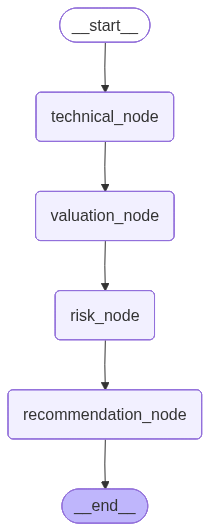

In [31]:
display(Image(analysis_agent.get_graph().draw_mermaid_png()))

In [32]:
symbols = ["AAPL", "MSFT", "GOOGL"]

for symbol in symbols:
    print(f"\n{'=' * 60}")
    print(f"Running Analysis Agent for: {symbol}")
    print("=" * 60)

    raw_data = data_agent.invoke(
        {"symbol": symbol, "period": "1y", "retry_count": 0, "errors": []}
    )

    analysis_input: AnalysisAgentState = {
        "symbol": raw_data["symbol"],
        "current_price": raw_data["current_price"],
        "high_52w": raw_data["high_52w"],
        "low_52w": raw_data["low_52w"],
        "price_change_pct": raw_data["price_change_pct"],
        "price_history": raw_data["price_history"],
        "pe_ratio": raw_data["pe_ratio"],
        "eps": raw_data["eps"],
        "market_cap": raw_data["market_cap"],
        "revenue": raw_data["revenue"],
        "profit_margin": raw_data["profit_margin"],
        "beta": raw_data["beta"],
        "dividend_yield": raw_data["dividend_yield"],
        "sector": raw_data["sector"],
        "data_summary": raw_data["summary"],
        "errors": [],
    }

    result = analysis_agent.invoke(analysis_input)

    print("\n── Final Output ─────────────────────────────")
    print(f"Symbol:         {result['symbol']}")
    print(f"RSI:            {result.get('rsi')}")
    print(f"Golden Cross:   {result.get('golden_cross')}")
    print(f"P/E Signal:     {result.get('pe_signal')}")
    print(f"Momentum:       {result.get('momentum_signal')}")
    print(f"Risk Score:     {result.get('risk_score')}/10")
    print(f"Risk Label:     {result.get('risk_label')}")
    print(f"Recommendation: {result.get('recommendation', '').upper()}")
    print(f"Reasoning:      {result.get('reasoning')}")
    print(f"Errors:         {result.get('errors')}")


Running Analysis Agent for: AAPL
📈 Fetching price data for AAPL...
✅ fetch_price_node → AAPL @ $298.01
   52w High: $317.4 | 52w Low: $198.96
   Price change (1y): 48.85%
   History records: 251
📊 Fetching fundamentals for AAPL...
✅ fetch_fundamentals_node → AAPL
   Market Cap:    $4,376,979,046,000
   P/E Ratio:     36.08
   EPS:           8.26
   Profit Margin: 0.272
   Sector:        TECHNOLOGY
   Industry:      CONSUMER ELECTRONICS
🔍 Validating data for AAPL...
   Price fetch:        ✅
   Fundamentals fetch: ✅
   Retry count:        0/2
✅ validate_node → All data valid, proceeding
📝 Generating data summary for AAPL...
✅ summary_node → Summary generated

── Summary ──────────────────────────────
AAPL's current market capitalization stands at approximately $4.38 trillion, with a price-to-earnings ratio of 36.08 and earnings per share of $8.26. The company has generated $451.44 billion in revenue over the trailing 12 months, with a profit margin of 27.2%. AAPL's stock price has incre

# RAG Agent


In [20]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_astradb import AstraDBVectorStore

d:\ai-learning\finsight-ai\agent\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [21]:
embeddings = HuggingFaceEmbeddings(
    model_name="all-MiniLM-L6-v2",
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True},
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 12541.76it/s]


In [22]:
vector_store = AstraDBVectorStore(
    embedding=embeddings,
    collection_name=os.getenv("ASTRA_DB_COLLECTION"),
    token=os.getenv("ASTRA_DB_APPLICATION_TOKEN"),
    api_endpoint=os.getenv("ASTRA_DB_API_ENDPOINT"),
    metric="cosine",
)

In [23]:
class RAGAgentState(TypedDict):
    symbol: str
    mode: Literal["ingest", "query"]
    file_path: Optional[str]
    question: Optional[str]

    chunks: Optional[list[str]]
    sources: Optional[list[dict]]
    chunks_stored: Optional[int]

    retrieved_docs: Optional[list[str]]
    retrieved_sources: Optional[list[dict]]
    answer: Optional[str]

    errors: Optional[list[str]]


In [24]:
ingest_test_state: RAGAgentState = {
    "symbol": "AAPL",
    "mode": "ingest",
    "errors": [],
}

query_test_state: RAGAgentState = {
    "symbol": "AAPL",
    "mode": "query",
    "question": "What are the main risk factors for AAPL?",
    "errors": [],
}

### Route Node


In [25]:
def route_node(state: RAGAgentState) -> dict:
    mode = state.get("mode")
    symbol = state["symbol"]
    print(f"🔀 route_node → {symbol} | mode: {mode}")
    return {}

### Ingest Node


In [26]:
from pathlib import Path
from langchain_community.document_loaders import PyPDFLoader, TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

C:\Users\Prashant\AppData\Local\Temp\ipykernel_3924\3381221475.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader, TextLoader


In [27]:
def ingest_node(state: RAGAgentState) -> dict:
    symbol = state["symbol"]
    file_path = state.get("file_path")
    errors = state.get("errors", [])

    if not file_path:
        error = "No file_path provided for ingest"
        print(f"❌ {error}")
        return {"errors": errors + [error]}

    print(f"📄 Ingesting document for {symbol}: {file_path}")

    try:
        ext = Path(file_path).suffix.lower()
        if ext == ".pdf":
            loader = PyPDFLoader(file_path)
        elif ext == ".txt":
            loader = TextLoader(file_path)
        else:
            raise ValueError(f"Unsupported file type: {ext}")

        docs = loader.load()
        print(f"   Loaded {len(docs)} page(s)")

        splitter = RecursiveCharacterTextSplitter(
            chunk_size=512,
            chunk_overlap=64,
            separators=["\n\n", "\n", ".", " "],
        )
        split_docs = splitter.split_documents(docs)
        print(f"   Split into {len(split_docs)} chunks")

        chunks = [doc.page_content for doc in split_docs]
        sources = [
            {
                "symbol": symbol,
                "filename": Path(file_path).name,
                "page": doc.metadata.get("page", 0),
                "chunk_index": i,
                "char_count": len(doc.page_content),
            }
            for i, doc in enumerate(split_docs)
        ]

        print(f"✅ ingest_node → {len(chunks)} chunks ready for {symbol}")
        return {
            "chunks": chunks,
            "sources": sources,
            "errors": errors,
        }

    except Exception as e:
        error = f"ingest_node error: {str(e)}"
        print(f"❌ {error}")
        return {"errors": errors + [error]}

### Embed Node


In [28]:
from langchain_core.documents import Document

In [29]:
def embed_node(state: RAGAgentState) -> dict:
    symbol = state["symbol"]
    chunks = state.get("chunks", [])
    sources = state.get("sources", [])
    errors = state.get("errors", [])

    if not chunks:
        error = "No chunks to embed"
        print(f"❌ {error}")
        return {"errors": errors + [error]}

    print(f"⏳ Embedding {len(chunks)} chunks for {symbol}...")

    documents = [
        Document(
            page_content=chunk,
            metadata=sources[i] if i < len(sources) else {"symbol": symbol},
        )
        for i, chunk in enumerate(chunks)
    ]

    inserted_ids = vector_store.add_documents(documents)

    print(f"✅ embed_node → {len(inserted_ids)} chunks upserted for {symbol}")
    return {
        "chunks_stored": len(inserted_ids),
        "errors": errors,
    }

### Retrieve Node


In [30]:
SIMILARITY_THRESHOLD = 0.65

In [32]:
def retrieve_node(state: RAGAgentState) -> dict:
    symbol = state["symbol"]
    question = state.get("question")
    errors = state.get("errors", [])

    if not question:
        error = "No question provided for retrieval"
        print(f"❌ {error}")
        return {"errors": errors + [error]}

    print(f"🔍 Retrieving docs for {symbol}: '{question}'")

    results = vector_store.similarity_search_with_score(
        query=question,
        k=4,
        filter={"symbol": symbol},
    )

    if not results:
        print(f"⚠️  No results found for {symbol}")
        return {
            "retrieved_docs": [],
            "retrieved_sources": [],
            "errors": errors,
        }

    retrieved_docs = []
    retrieved_sources = []

    for doc, score in results:
        if score >= SIMILARITY_THRESHOLD:
            retrieved_docs.append(doc.page_content)
            retrieved_sources.append(
                {
                    **doc.metadata,
                    "similarity_score": round(score, 4),
                }
            )
            print(f"   Score: {round(score, 4)} | {doc.page_content[:80]}...")
        else:
            print(f"   ⚠️ Discarded (score: {round(score, 4)}) — below threshold")

    print(f"✅ retrieve_node → {len(retrieved_docs)} relevant chunks for {symbol}")
    return {
        "retrieved_docs": retrieved_docs,
        "retrieved_sources": retrieved_sources,
        "errors": errors,
    }

### Answer Node


In [33]:
RAG_SYSTEM_PROMPT = """
You are FinSight, an AI financial analyst assistant.
Answer the user's question strictly based on the provided document context.

Rules:
1. Answer ONLY from the provided context
2. If context is insufficient say: "I don't have enough information in the uploaded documents to answer this."
3. Always cite the source filename and page number
4. Be concise and precise — financial accuracy matters
5. Never speculate beyond what the documents say
"""


In [34]:
def answer_node(state: RAGAgentState) -> dict:
    symbol = state["symbol"]
    question = state.get("question")
    retrieved_docs = state.get("retrieved_docs", [])
    sources = state.get("retrieved_sources", [])
    errors = state.get("errors", [])

    print(f"💬 Generating answer for {symbol}: '{question}'")

    if not retrieved_docs:
        answer = (
            "I don't have enough information in the uploaded "
            f"documents to answer this question about {symbol}."
        )
        print("⚠️  No retrieved docs — returning default answer")
        return {"answer": answer, "errors": errors}

    context = "\n\n---\n\n".join(
        [
            f"[Source: {src.get('filename', 'unknown')}, Page {src.get('page', 0)}]\n{doc}"
            for doc, src in zip(retrieved_docs, sources)
        ]
    )

    prompt = f"""
    Context from {symbol} financial documents:

    {context}

    Question: {question}

    Answer based strictly on the context above.
    """

    try:
        response = groq_client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[
                {"role": "system", "content": RAG_SYSTEM_PROMPT},
                {"role": "user", "content": prompt},
            ],
            temperature=0.1,
        )
        answer = response.choices[0].message.content.strip()
        print(f"✅ answer_node → Answer generated for {symbol}")
        print("\n── Answer ───────────────────────────────")
        print(answer)
        return {"answer": answer, "errors": errors}

    except Exception as e:
        error = f"answer_node error: {str(e)}"
        print(f"❌ {error}")
        return {
            "answer": "Unable to generate answer due to an error.",
            "errors": errors + [error],
        }

### GRAPH

In [35]:
def route_by_mode(state: RAGAgentState) -> str:
    mode = state.get("mode")
    if mode == "ingest":
        return "ingest_node"
    return "retrieve_node"

In [36]:
def build_rag_agent():
    graph = StateGraph(RAGAgentState)

    graph.add_node("route_node",    route_node)
    graph.add_node("ingest_node",   ingest_node)
    graph.add_node("embed_node",    embed_node)
    graph.add_node("retrieve_node", retrieve_node)
    graph.add_node("answer_node",   answer_node)

    graph.set_entry_point("route_node")

    graph.add_conditional_edges(
        "route_node",
        route_by_mode,
        {
            "ingest_node":   "ingest_node",
            "retrieve_node": "retrieve_node",
        }
    )

    graph.add_edge("ingest_node", "embed_node")
    graph.add_edge("embed_node",  END)

    graph.add_edge("retrieve_node", "answer_node")
    graph.add_edge("answer_node",   END)

    return graph.compile()


In [37]:
rag_agent = build_rag_agent()


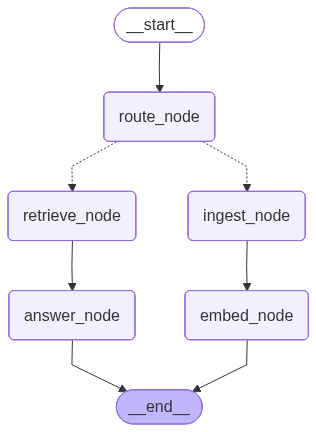

In [38]:
display(Image(rag_agent.get_graph().draw_mermaid_png()))

In [40]:
# create a fake AAPL annual report excerpt for testing
test_doc_path = Path.cwd() / "aapl_annual_report.txt"

test_doc_path.write_text("""
APPLE INC. — ANNUAL REPORT EXCERPT 2024

RISK FACTORS

1. Global Economic Conditions
Apple's business is subject to risks from global economic conditions including
inflation, interest rate changes, and currency fluctuations. A downturn in 
consumer spending could adversely affect iPhone and Mac sales.

2. Supply Chain Concentration
Apple relies heavily on suppliers in Asia, particularly Taiwan and China.
Geopolitical tensions or natural disasters could disrupt production significantly.
The company has been diversifying manufacturing to India and Vietnam.

3. Competition
Apple faces intense competition from Samsung, Google, and Chinese manufacturers
in the smartphone market. The services segment faces competition from Spotify,
Netflix, and other digital content providers.

4. Regulatory Risk
Apple faces ongoing antitrust investigations in the EU and US regarding the
App Store policies and fees. The Digital Markets Act in Europe may require
significant changes to Apple's business practices.

FINANCIAL HIGHLIGHTS 2024

Revenue:          $451.4 billion (up 2% YoY)
Net Income:       $122.7 billion (up 4% YoY)
Gross Margin:     46.2%
Services Revenue: $96.2 billion (up 13% YoY)
iPhone Revenue:   $201.2 billion (down 1% YoY)
Cash Position:    $162.1 billion

BUSINESS SEGMENTS

iPhone accounted for 44.6% of total revenue.
Services grew to 21.3% of revenue — highest ever.
Mac revenue was $29.4 billion, up 7% YoY.
iPad revenue was $26.7 billion, down 6% YoY.
Wearables revenue was $37.0 billion, down 3% YoY.

OUTLOOK

Management expects continued growth in Services segment.
AI features (Apple Intelligence) launching across product line.
Vision Pro spatial computing platform in early adoption phase.
Capital return program: $110 billion buyback authorized.
""")

print(f"✅ Test document created: {test_doc_path}")

✅ Test document created: d:\ai-learning\finsight-ai\agent\notebooks\aapl_annual_report.txt


In [41]:
ingest_result = rag_agent.invoke({
    "symbol":            "AAPL",
    "mode":              "ingest",
    "file_path":         str(test_doc_path),
    "errors":            [],
})

print("\n── Ingest Result ────────────────────────────")
print(f"Chunks stored: {ingest_result.get('chunks_stored')}")
print(f"Errors:        {ingest_result.get('errors')}")

🔀 route_node → AAPL | mode: ingest
📄 Ingesting document for AAPL: d:\ai-learning\finsight-ai\agent\notebooks\aapl_annual_report.txt
   Loaded 1 page(s)
   Split into 4 chunks
✅ ingest_node → 4 chunks ready for AAPL
⏳ Embedding 4 chunks for AAPL...
✅ embed_node → 4 chunks upserted for AAPL

── Ingest Result ────────────────────────────
Chunks stored: 4
Errors:        []


In [42]:
test_questions = [
    "What are the main risk factors for AAPL?",
    "What was Apple's revenue in 2024?",
    "How is Apple's services segment performing?",
    "What is Apple's cash position?",
]

for question in test_questions:
    print(f"\n{'='*60}")
    print(f"Question: {question}")
    print('='*60)

    query_result = rag_agent.invoke({
        "symbol":            "AAPL",
        "mode":              "query",
        "question":          question,
        "errors":            [],
    })

    print(f"\nAnswer:\n{query_result.get('answer')}")
    print(f"Errors: {query_result.get('errors')}")


Question: What are the main risk factors for AAPL?
🔀 route_node → AAPL | mode: query
🔍 Retrieving docs for AAPL: 'What are the main risk factors for AAPL?'
   Score: 0.7459 | APPLE INC. — ANNUAL REPORT EXCERPT 2024

RISK FACTORS

1. Global Economic Condit...
   ⚠️ Discarded (score: 0.6238) — below threshold
   ⚠️ Discarded (score: 0.6172) — below threshold
   ⚠️ Discarded (score: 0.5888) — below threshold
✅ retrieve_node → 1 relevant chunks for AAPL
💬 Generating answer for AAPL: 'What are the main risk factors for AAPL?'
✅ answer_node → Answer generated for AAPL

── Answer ───────────────────────────────
According to the provided context, the main risk factor mentioned for AAPL is global economic conditions, which includes inflation, interest rate changes, and currency fluctuations [Source: aapl_annual_report.txt, Page 0].

Answer:
According to the provided context, the main risk factor mentioned for AAPL is global economic conditions, which includes inflation, interest rate changes, 